# 反馈评分预测

导包

In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go

# 导入自然语言处理工具
import nltk
from nltk.corpus import stopwords
from wordcloud import WordCloud

# 导入深度学习框架及预处理工具
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

# 导入机器学习评估指标
from sklearn.metrics import auc
from sklearn.metrics import classification_report
from sklearn.metrics import roc_auc_score
from sklearn.metrics import confusion_matrix

# 忽略警告信息
import warnings
warnings.filterwarnings('ignore')
# 设置Jupyter Notebook内嵌图表显示
%matplotlib inline

设参

In [2]:
input_dir = "data/olist_public_dataset/olist_order_reviews_dataset.csv"

# 训练参数
RANDOM_STATE = 12
TRAIN_SPLIT = 0.80
BATCH_SIZE=128  # 批处理大小
EPOCHS=500  # 最大训练轮次
EARLY_STOPPING_CRITERIA=3

# 文本处理参数
OOV_TOK = "<OOV>"
VOCAB_SIZE = 10000
MAX_LENGTH = 120

# 模型架构参数
EMBEDDING_DIM = 16

DROPOUT_P=0.4

# 优化器参数
LEARNING_RATE = 0.01
MOMENTUM =0.9

# 辅助参数
MAX_ITER = 10000
N_JOBS = 4


In [3]:
# 查看数据头
data = pd.read_csv(input_dir)
data.head()

,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
0,7bc2406110b926393aa56f80a40eba40,73fc7af87114b39712e6da79b0a377eb,4,NaN,NaN,2018-01-18 00:00:00,2018-01-18 21:46:59
1,80e641a11e56f04c1ad469d5645fdfde,a548910a1c6147796b98fdf73dbeba33,5,NaN,NaN,2018-03-10 00:00:00,2018-03-11 03:05:13
2,228ce5500dc1d8e020d8d1322874b6f0,f9e4b658b201a9f2ecdecbb34bed034b,5,NaN,NaN,2018-02-17 00:00:00,2018-02-18 14:36:24
3,e64fb393e7b32834bb789ff8bb30750e,658677c97b385a9be170737859d3511b,5,NaN,Recebi bem antes do prazo estipulado.,2017-04-21 00:00:00,2017-04-21 22:02:06
4,f7c4243c7fe1938f181bec41a392bdeb,8e6bfb81e283fa7e4f11123a3fb894f1,5,NaN,Parabéns lojas lannister adorei comprar pela I...,2018-03-01 00:00:00,2018-03-02 10:26:53


数据分布

In [4]:
def clean_data(data, column_text='review_comment_message', 
               column_score='review_score', 
               points_cut=[0, 3, 5],  
               classes=[0, 1]):
    """统一数据处理流程（已添加返回值）"""
    # 处理二分类数据
    df_bin = data.copy()
    df_bin = df_bin.dropna(subset=[column_text])
    df_bin['label'] = pd.cut(df_bin[column_score], 
                            bins=points_cut, 
                            labels=classes,
                            include_lowest=True)
    df_bin['label'] = df_bin['label'].astype(int)
    df_bin = df_bin.rename(columns={column_text: 'text'})[['text','label']]
    
    # 处理多分类数据
    df_cat = data.copy()
    df_cat = df_cat.dropna(subset=[column_text])
    df_cat = df_cat.rename(columns={column_text: 'text', 
                                   column_score: 'label'})
    df_cat['label'] = df_cat['label'].astype(int)
    df_cat = df_cat[['text','label']]
    
    return df_bin, df_cat  # 添加返回值


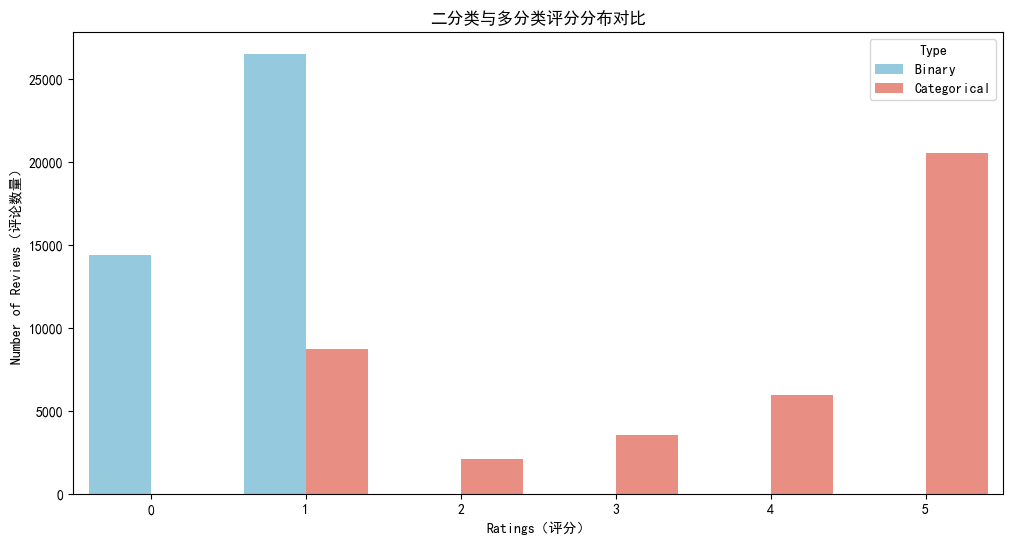

In [5]:

plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False
df_bin, df_cat = clean_data(data)
def plot_combined_rating_distribution(df_bin, df_cat):
    # 计算二分类和多分类的评分分布
    rating_counts_bin = df_bin['label'].value_counts().sort_index()
    rating_counts_cat = df_cat['label'].value_counts().sort_index()
    
    # 创建一个 DataFrame 来保存数据
    import pandas as pd
    combined_data = pd.DataFrame({
        'Rating': rating_counts_bin.index.tolist() + rating_counts_cat.index.tolist(),
        'Number of Reviews': rating_counts_bin.values.tolist() + rating_counts_cat.values.tolist(),
        'Type': ['Binary'] * len(rating_counts_bin) + ['Categorical'] * len(rating_counts_cat)
    })
    
    # 设置图形大小
    plt.figure(figsize=(12, 6))
    
    # 绘制条形图
    sns.barplot(x='Rating', y='Number of Reviews', hue='Type', data=combined_data, palette=['skyblue', 'salmon'])
    
    # 添加标题和轴标签
    plt.title('二分类与多分类评分分布对比')
    plt.xlabel('Ratings（评分）')
    plt.ylabel('Number of Reviews（评论数量）')
    
    # 显示图形
    plt.show()

# 绘制合并的评分分布图
plot_combined_rating_distribution(df_bin, df_cat)


由于 5 个不同评分类别的数据不平衡，我们将改为研究二元分类问题。输出将为 0 和 1，分别代表不开心和开心。词云分析：

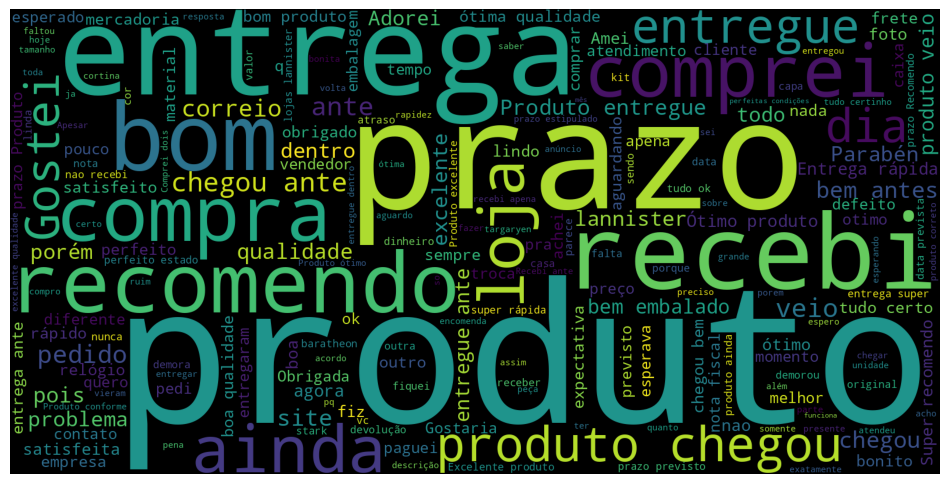

In [6]:
import pandas as pd
from wordcloud import WordCloud
import matplotlib.pyplot as plt
from nltk.corpus import stopwords

df_bin, df_cat = clean_data(data)
# 假设 data_bin["text"] 已经被定义并包含文本数据
stop_words = stopwords.words('portuguese')
wordcloud = WordCloud(stopwords=stop_words,
                      background_color="black",
                      width=1600, height=800).generate(' '.join(df_bin["text"]))


fig, ax = plt.subplots(figsize=(12, 10))
ax.imshow(wordcloud, interpolation='bilinear')
ax.set_axis_off()
wordcloud.to_file('wordcloud.png')
plt.imshow(wordcloud)

df = pd.DataFrame(df_bin["text"], columns=['text'])  
df.to_csv('data_text.csv', index=False)  

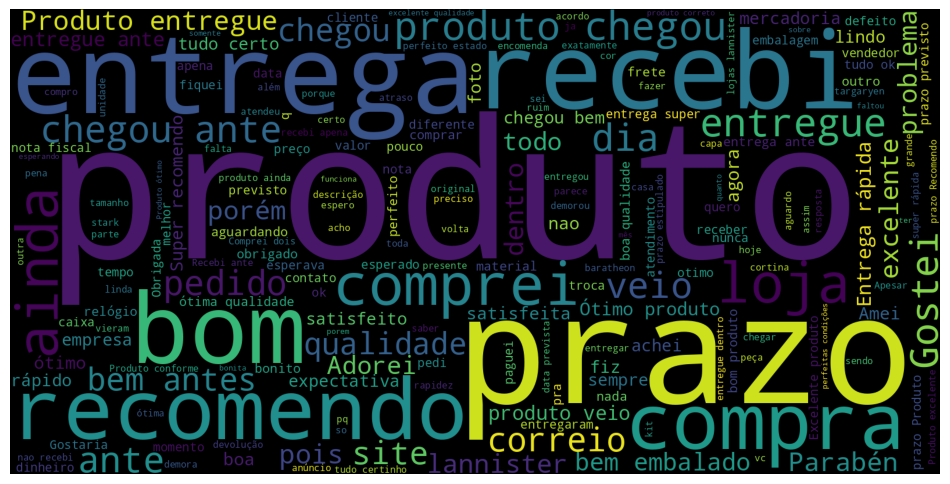

In [7]:
stop_words = stopwords.words('portuguese')
wordcloud = WordCloud(stopwords=stop_words,
                      background_color="black",
                      width=1600, height=800).generate(' '.join(df_bin["text"]))
fig, ax = plt.subplots(figsize=(12,10))
ax.imshow(wordcloud, interpolation='bilinear')
ax.set_axis_off()
plt.imshow(wordcloud);


In [8]:
from tqdm import tqdm
from sklearn.model_selection import train_test_split

def split_test_train(data, split_train=TRAIN_SPLIT, random_state=RANDOM_STATE):
    df_train = data.sample(
        frac = split_train, 
        random_state = random_state
        )
    df_test = data.drop(df_train.index)
    
    
    """
    数据集分割与预处理
    
    Args:
        data: 包含 text 和 label 列的 DataFrame
        test_size: 测试集比例 (默认 0.2)
        random_state: 随机种子
    
    Returns:
        (X_train, X_test, y_train, y_test)
    """

    X_train = []
    y_train = []
    X_test = []
    y_test = []
    
    for index, train in tqdm(df_train.iterrows(), total=len(df_train), desc="Processing Train"):
        X_train.append(str(train['text']))
        y_train.append(train['label'])
    
    for index, test in tqdm(df_test.iterrows(), total=len(df_test), desc="Processing Test"):
        X_test.append(str(test['text']))
        y_test.append(test['label'])
        
    y_train = np.array(y_train)
    y_test = np.array(y_test)   
    
    return X_train , y_train , X_test , y_test


X_train , y_train , X_test , y_test = split_test_train(df_bin, split_train=TRAIN_SPLIT, random_state=RANDOM_STATE)
# 在模型训练时显示进度条



Processing Test: 100%|██████████| 8195/8195 [00:00<00:00, 57024.98it/s]


In [9]:

# 初始化文本分词器，构建词汇表
tokenizer = Tokenizer(num_words = VOCAB_SIZE, oov_token=OOV_TOK)
# 在训练集文本上拟合分词器，生成词汇索引
tokenizer.fit_on_texts(X_train)

# 定义文本预处理函数，用于序列化和填充文本数据
def preprocess(X_train, X_test, max_length, vocab_size, trunc_type='post', oov_tok = "<OOV>"):
    # 将训练文本转换为索引序列并进行长度标准化处理
    training_sequences = tokenizer.texts_to_sequences(X_train)
    X_train_padded = pad_sequences(training_sequences,
                                   maxlen=max_length, 
                                   truncating=trunc_type)
    
    # 将测试文本转换为索引序列并进行长度标准化处理
    testing_sequences = tokenizer.texts_to_sequences(X_test)
    X_test_padded = pad_sequences(testing_sequences,
                                  maxlen=max_length)
    
    return X_train_padded, X_test_padded

# 调用预处理函数生成标准化后的训练集和测试集
X_train, X_test = preprocess(X_train, X_test, MAX_LENGTH, VOCAB_SIZE)

**NN-LSTM 模型**

In [ ]:
def create_model(max_length, vocab_size, embedding_dim, dropout_p=0.2):
    # 更清晰的层级结构
    inputs = tf.keras.Input(shape=(max_length,))
    
    # 嵌入层 + 双向LSTM
    x = tf.keras.layers.Embedding(vocab_size, embedding_dim)(inputs)
    x = tf.keras.layers.Bidirectional(tf.keras.layers.LSTM(64, return_sequences=True))(x)
    x = tf.keras.layers.LSTM(32)(x)
    
    # 正则化模块
    x = tf.keras.layers.Dropout(dropout_p)(x)
    
    # 全连接模块
    x = tf.keras.layers.Dense(256, activation="relu", kernel_regularizer="l2")(x)
    x = tf.keras.layers.Dropout(dropout_p)(x)
    outputs = tf.keras.layers.Dense(1, activation="sigmoid")(x)
    
    return tf.keras.Model(inputs=inputs, outputs=outputs)


# 定义神经网络模型构建函数，返回编译前的模型实例
def create_model():
    
    # 定义模型输入层，处理最大长度为MAX_LENGTH的序列
    input = tf.keras.Input(shape=(MAX_LENGTH))
    
    # 构建嵌入层和LSTM层结构
    x = tf.keras.layers.Embedding(VOCAB_SIZE, EMBEDDING_DIM, input_length=MAX_LENGTH)(input)
    x = tf.keras.layers.LSTM(32, return_sequences=True)(x)  # 第一层LSTM返回完整序列
    x = tf.keras.layers.LSTM(32)(x)  # 第二层LSTM仅返回最后时间步输出
    x = tf.keras.layers.Dropout(DROPOUT_P)(x)  # 添加随机失活防止过拟合
    
    # 构建全连接分类器部分
    x = tf.keras.layers.Dense(800, activation='relu')(x)  # 首层全连接含800个神经元
    x = tf.keras.layers.Dropout(DROPOUT_P)(x)
    x = tf.keras.layers.Dense(400, activation='relu')(x)  # 次层全连接含400个神经元
    x = tf.keras.layers.Dropout(DROPOUT_P)(x)
    output = tf.keras.layers.Dense(1, activation='sigmoid')(x)  # 二分类输出层
    
    # 组合输入输出构建完整模型
    model = tf.keras.Model(input, output)

    return model

In [11]:
def create_model():
    input = tf.keras.Input(shape=(MAX_LENGTH,))
    x = tf.keras.layers.Embedding(VOCAB_SIZE, EMBEDDING_DIM, input_length=MAX_LENGTH)(input)
    x = tf.keras.layers.LSTM(32)(x)  # 注意这里改变了
    output = tf.keras.layers.Dense(1, activation='sigmoid')(x)  # 对于二分类
    return tf.keras.Model(inputs=input, outputs=output)

model = create_model()
model.compile(
    loss=tf.keras.losses.BinaryCrossentropy(),
    optimizer=tf.keras.optimizers.SGD(learning_rate=LEARNING_RATE, momentum=MOMENTUM),
    metrics=['accuracy']
)
optimizer = tf.keras.optimizers.Adam(
    learning_rate=tf.keras.optimizers.schedules.ExponentialDecay(
        initial_learning_rate=1e-3,
        decay_steps=10000,
        decay_rate=0.96
    )
)


**训练 LSTM 模型**

In [12]:


# 创建早停回调实例用于防止过拟合
earlyStoppingCallback = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=EARLY_STOPPING_CRITERIA,
    verbose=1,
    restore_best_weights=True
    
)
# 初始化模型架构
model = create_model()  # 确保您有定义 create_model 函数

# 配置模型训练参数（损失函数、优化器、评估指标）
model.compile(
    loss=tf.keras.losses.BinaryCrossentropy(),
    optimizer=tf.keras.optimizers.SGD(learning_rate=LEARNING_RATE, momentum=MOMENTUM),
    metrics=['accuracy']
)

# 打印模型结构摘要信息
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 120)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding_1 (Embedding)         │ (None, 120, 16)        │       160,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │         6,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 166,305 (649.63 KB)

 Trainable params: 166,305 (649.63 KB)

 Non-trainable params: 0 (0.00 B)

In [13]:
history = model.fit(
    x=X_train,
    y=y_train,
    validation_data=(X_test, y_test),
    
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=[earlyStoppingCallback]
)

Epoch 1/500
257/257 ━━━━━━━━━━━━━━━━━━━━ 7s 25ms/step - accuracy: 0.6457 - loss: 0.6451 - val_accuracy: 0.7246 - val_loss: 0.5572
Epoch 2/500
257/257 ━━━━━━━━━━━━━━━━━━━━ 6s 22ms/step - accuracy: 0.7301 - loss: 0.5484 - val_accuracy: 0.8020 - val_loss: 0.4916
Epoch 3/500
257/257 ━━━━━━━━━━━━━━━━━━━━ 5s 21ms/step - accuracy: 0.7914 - loss: 0.4686 - val_accuracy: 0.8200 - val_loss: 0.4262
Epoch 4/500
257/257 ━━━━━━━━━━━━━━━━━━━━ 6s 22ms/step - accuracy: 0.8312 - loss: 0.4067 - val_accuracy: 0.8520 - val_loss: 0.3635
Epoch 5/500
257/257 ━━━━━━━━━━━━━━━━━━━━ 5s 21ms/step - accuracy: 0.8541 - loss: 0.3521 - val_accuracy: 0.8593 - val_loss: 0.3399
Epoch 6/500
257/257 ━━━━━━━━━━━━━━━━━━━━ 6s 24ms/step - accuracy: 0.8671 - loss: 0.3289 - val_accuracy: 0.8652 - val_loss: 0.3307
Epoch 7/500
257/257 ━━━━━━━━━━━━━━━━━━━━ 6s 25ms/step - accuracy: 0.8745 - loss: 0.3163 - val_accuracy: 0.8777 - val_loss: 0.3098
Epoch 8/500
257/257 ━━━━━━━━━━━━━━━━━━━━ 7s 28ms/step - accuracy: 0.8856 - loss: 0.2960 - 

可视化训练结果

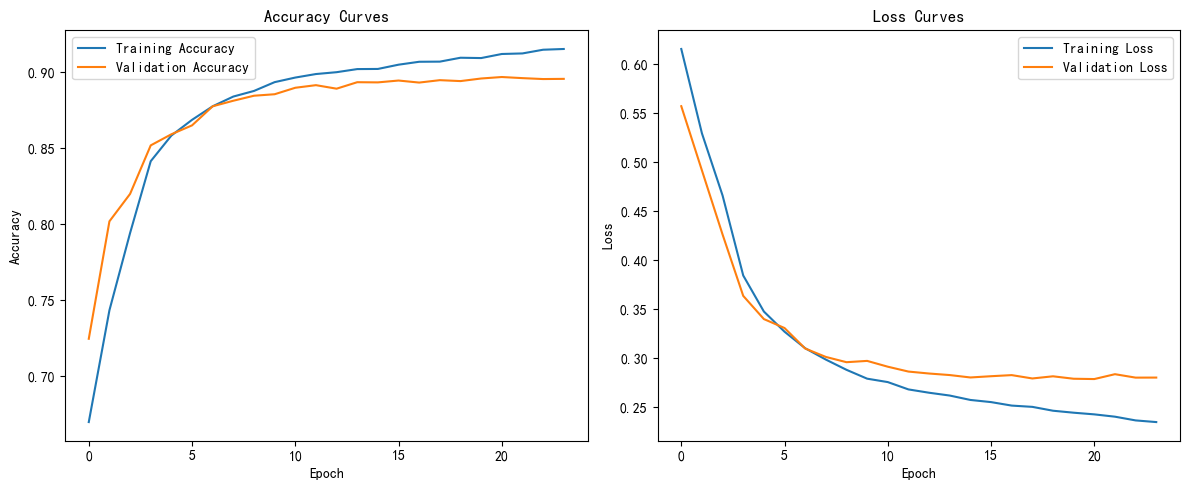

In [14]:
import matplotlib.pyplot as plt

# 假设您的训练代码是这样的（需要补充）：
# history = model.fit(X_train, y_train,
#                     epochs=EPOCHS,
#                     validation_data=(X_val, y_val),
#                     callbacks=[earlyStoppingCallback])

# 绘制训练曲线
def plot_training_history(history):
    # 创建两个子图
    plt.figure(figsize=(12, 5))
    
    # 准确率曲线
    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'], label='Training Accuracy')
    plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
    plt.title('Accuracy Curves')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()
    
    # 损失函数曲线
    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'], label='Training Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.title('Loss Curves')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    
    plt.tight_layout()
    plt.savefig('training_history.png')
    plt.show()
# 调用可视化函数
plot_training_history(history)


                          review_id                          order_id  \
0  7bc2406110b926393aa56f80a40eba40  73fc7af87114b39712e6da79b0a377eb   
1  80e641a11e56f04c1ad469d5645fdfde  a548910a1c6147796b98fdf73dbeba33   
2  228ce5500dc1d8e020d8d1322874b6f0  f9e4b658b201a9f2ecdecbb34bed034b   
3  e64fb393e7b32834bb789ff8bb30750e  658677c97b385a9be170737859d3511b   
4  f7c4243c7fe1938f181bec41a392bdeb  8e6bfb81e283fa7e4f11123a3fb894f1   

   review_score review_comment_title  \
0             4                  NaN   
1             5                  NaN   
2             5                  NaN   
3             5                  NaN   
4             5                  NaN   

                              review_comment_message review_creation_date  \
0                                                NaN  2018-01-18 00:00:00   
1                                                NaN  2018-03-10 00:00:00   
2                                                NaN  2018-02-17 00:00:00   
3           

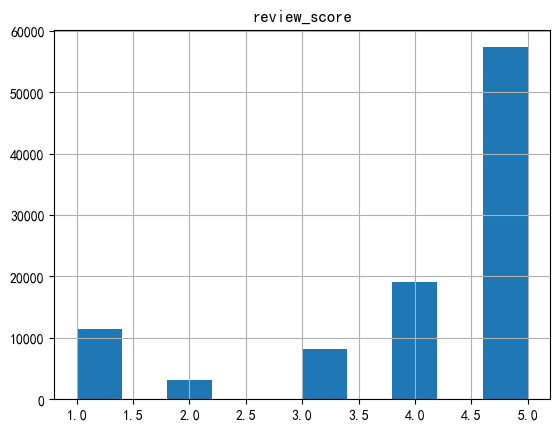

<Figure size 640x480 with 0 Axes>

In [15]:

print(data.head())
print(data.describe())
import matplotlib.pyplot as plt
data.hist()
plt.show()
plt.savefig('data_distribution.png')


In [16]:
print(history.history.keys())  # 确认存在'acc'/'accuracy'等键

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])


**评估 LSTM 模型**

In [17]:
y_preds_prob = model.predict(X_test, verbose=0)
y_preds = np.where(y_preds_prob> 0.5, 1, 0)
y_preds_prob = y_preds_prob[:, 0]
y_preds = y_preds[:, 0]

[loss,accuracy] = model.evaluate(X_test, y_test ,verbose = 0 )
print("Accuracy on Test Data :", accuracy*100 ,"%")
print(classification_report(y_test ,y_preds))

Accuracy on Test Data : 89.70103859901428 %
              precision    recall  f1-score   support

           0       0.87      0.84      0.85      2937
           1       0.91      0.93      0.92      5258

    accuracy                           0.90      8195
   macro avg       0.89      0.88      0.89      8195
weighted avg       0.90      0.90      0.90      8195



In [18]:
import plotly.graph_objects as go
import pandas as pd

cm_data = confusion_matrix(y_test, y_preds)
cm = pd.DataFrame(cm_data, columns=[0, 1], index=[0, 1])
cm.index.name = 'Actual'
cm.columns.name = 'Predicted'

fig = go.Figure(data=go.Heatmap(
                   z=cm.values,x=cm.columns,y=cm.index,
                   colorscale='Blues',text=cm.values,texttemplate="%{text}",textfont={"size": 16}))
fig.update_layout(
    title='Confusion Matrix',
    xaxis_title='Predicted',yaxis_title='Actual',
    font=dict(size=16),autosize=False,
    width=800,height=600,margin=dict(l=50, r=50, b=100, t=100, pad=4))
fig.show()


**与其他模型的比较**

In [19]:
# 反馈评分预测
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

逻辑回归

In [20]:
lr = LogisticRegression(max_iter= MAX_ITER,random_state=RANDOM_STATE, n_jobs= N_JOBS)
lr.fit(X_train,y_train)
lr_preds = lr.predict(X_test)
print("Model score on Training Data = ", lr.score(X_train,y_train)*100,"%")
print("Model score on Testing Data = ", lr.score(X_test,y_test)*100,"%")

Model score on Training Data =  69.68153254834971 %
Model score on Testing Data =  68.63941427699817 %


朴素贝叶斯

In [21]:
nb = MultinomialNB()
nb.fit(X_train,y_train)
nb_preds = nb.predict(X_test)
print("Model score on Training Data = ", nb.score(X_train,y_train)*100 ,"%")
print("Model score on Testing Data = ", nb.score(X_test,y_test)*100 ,"%")

Model score on Training Data =  70.52955890427674 %
Model score on Testing Data =  70.44539353264186 %


支持向量分类器 (SVC)

In [22]:
svm = SVC(random_state=RANDOM_STATE , verbose = True)
svm.fit(X_train,y_train)
sv_preds = svm.predict(X_test)
print("Model score on Training Data = ", svm.score(X_train,y_train)*100 ,"%")
print("Model score on Testing Data = ", svm.score(X_test,y_test)*100 ,"%")

[LibSVM]Model score on Training Data =  75.25166249771216 %
Model score on Testing Data =  71.40939597315436 %


随机森林分类器

In [23]:
rfc = RandomForestClassifier(n_estimators = 100, random_state =RANDOM_STATE , n_jobs = N_JOBS)
rfc.fit(X_train,y_train)
rf_preds = rfc.predict(X_test)
print("Model score on Training Data = ", rfc.score(X_train,y_train)*100 ,"%")
print("Model score on Testing Data = ", rfc.score(X_test,y_test)*100 ,"%")

Model score on Training Data =  98.89573546458422 %
Model score on Testing Data =  77.09579011592434 %


XGBOOST 分类器

In [24]:
xgb = XGBClassifier(objective='binary:logistic' , 
                    use_label_encoder=False,  
                    random_state = RANDOM_STATE,
                    eval_metric='mlogloss')
xgb.fit(X_train,y_train)
xg_preds = xgb.predict(X_test)
print("Model score on Training Data = ", xgb.score(X_train,y_train)*100 ,"%")
print("Model score on Testing Data = ", xgb.score(X_test,y_test)*100 ,"%")

Model score on Training Data =  92.44097370508206 %
Model score on Testing Data =  82.34289200732154 %


**性能指标比较**

测试准确率比较

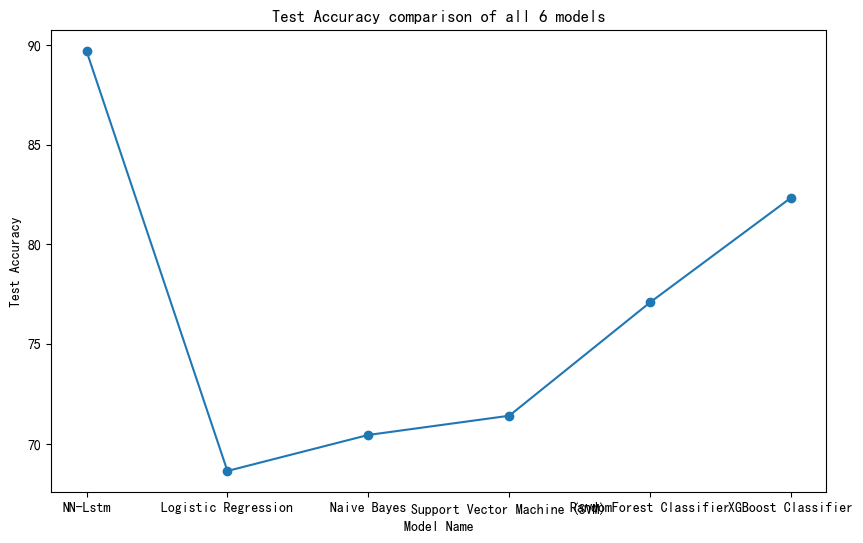

In [25]:

results = pd.DataFrame(data=[accuracy*100], columns=["NN-Lstm"], index=["Test Accuracy"])
results['Logistic Regression'] = lr.score(X_test, y_test) * 100
results['Naive Bayes'] = nb.score(X_test, y_test) * 100
results['Support Vector Machine (SVM)'] = svm.score(X_test, y_test) * 100
results['RandomForest Classifier'] = rfc.score(X_test, y_test) * 100
results['XGBoost Classifier'] = xgb.score(X_test, y_test) * 100
results = results.transpose()

# 绘制测试准确率对比图
fig, ax = plt.subplots(figsize=(10, 6))
# 绘制折线图
models = results.index
test_accuracy = results['Test Accuracy']
ax.plot(models, test_accuracy, marker='o')
# 设置x轴和y轴标签
ax.set_xlabel('Model Name')
ax.set_ylabel('Test Accuracy')
ax.set_title('Test Accuracy comparison of all 6 models')
plt.show()


混淆矩阵比较

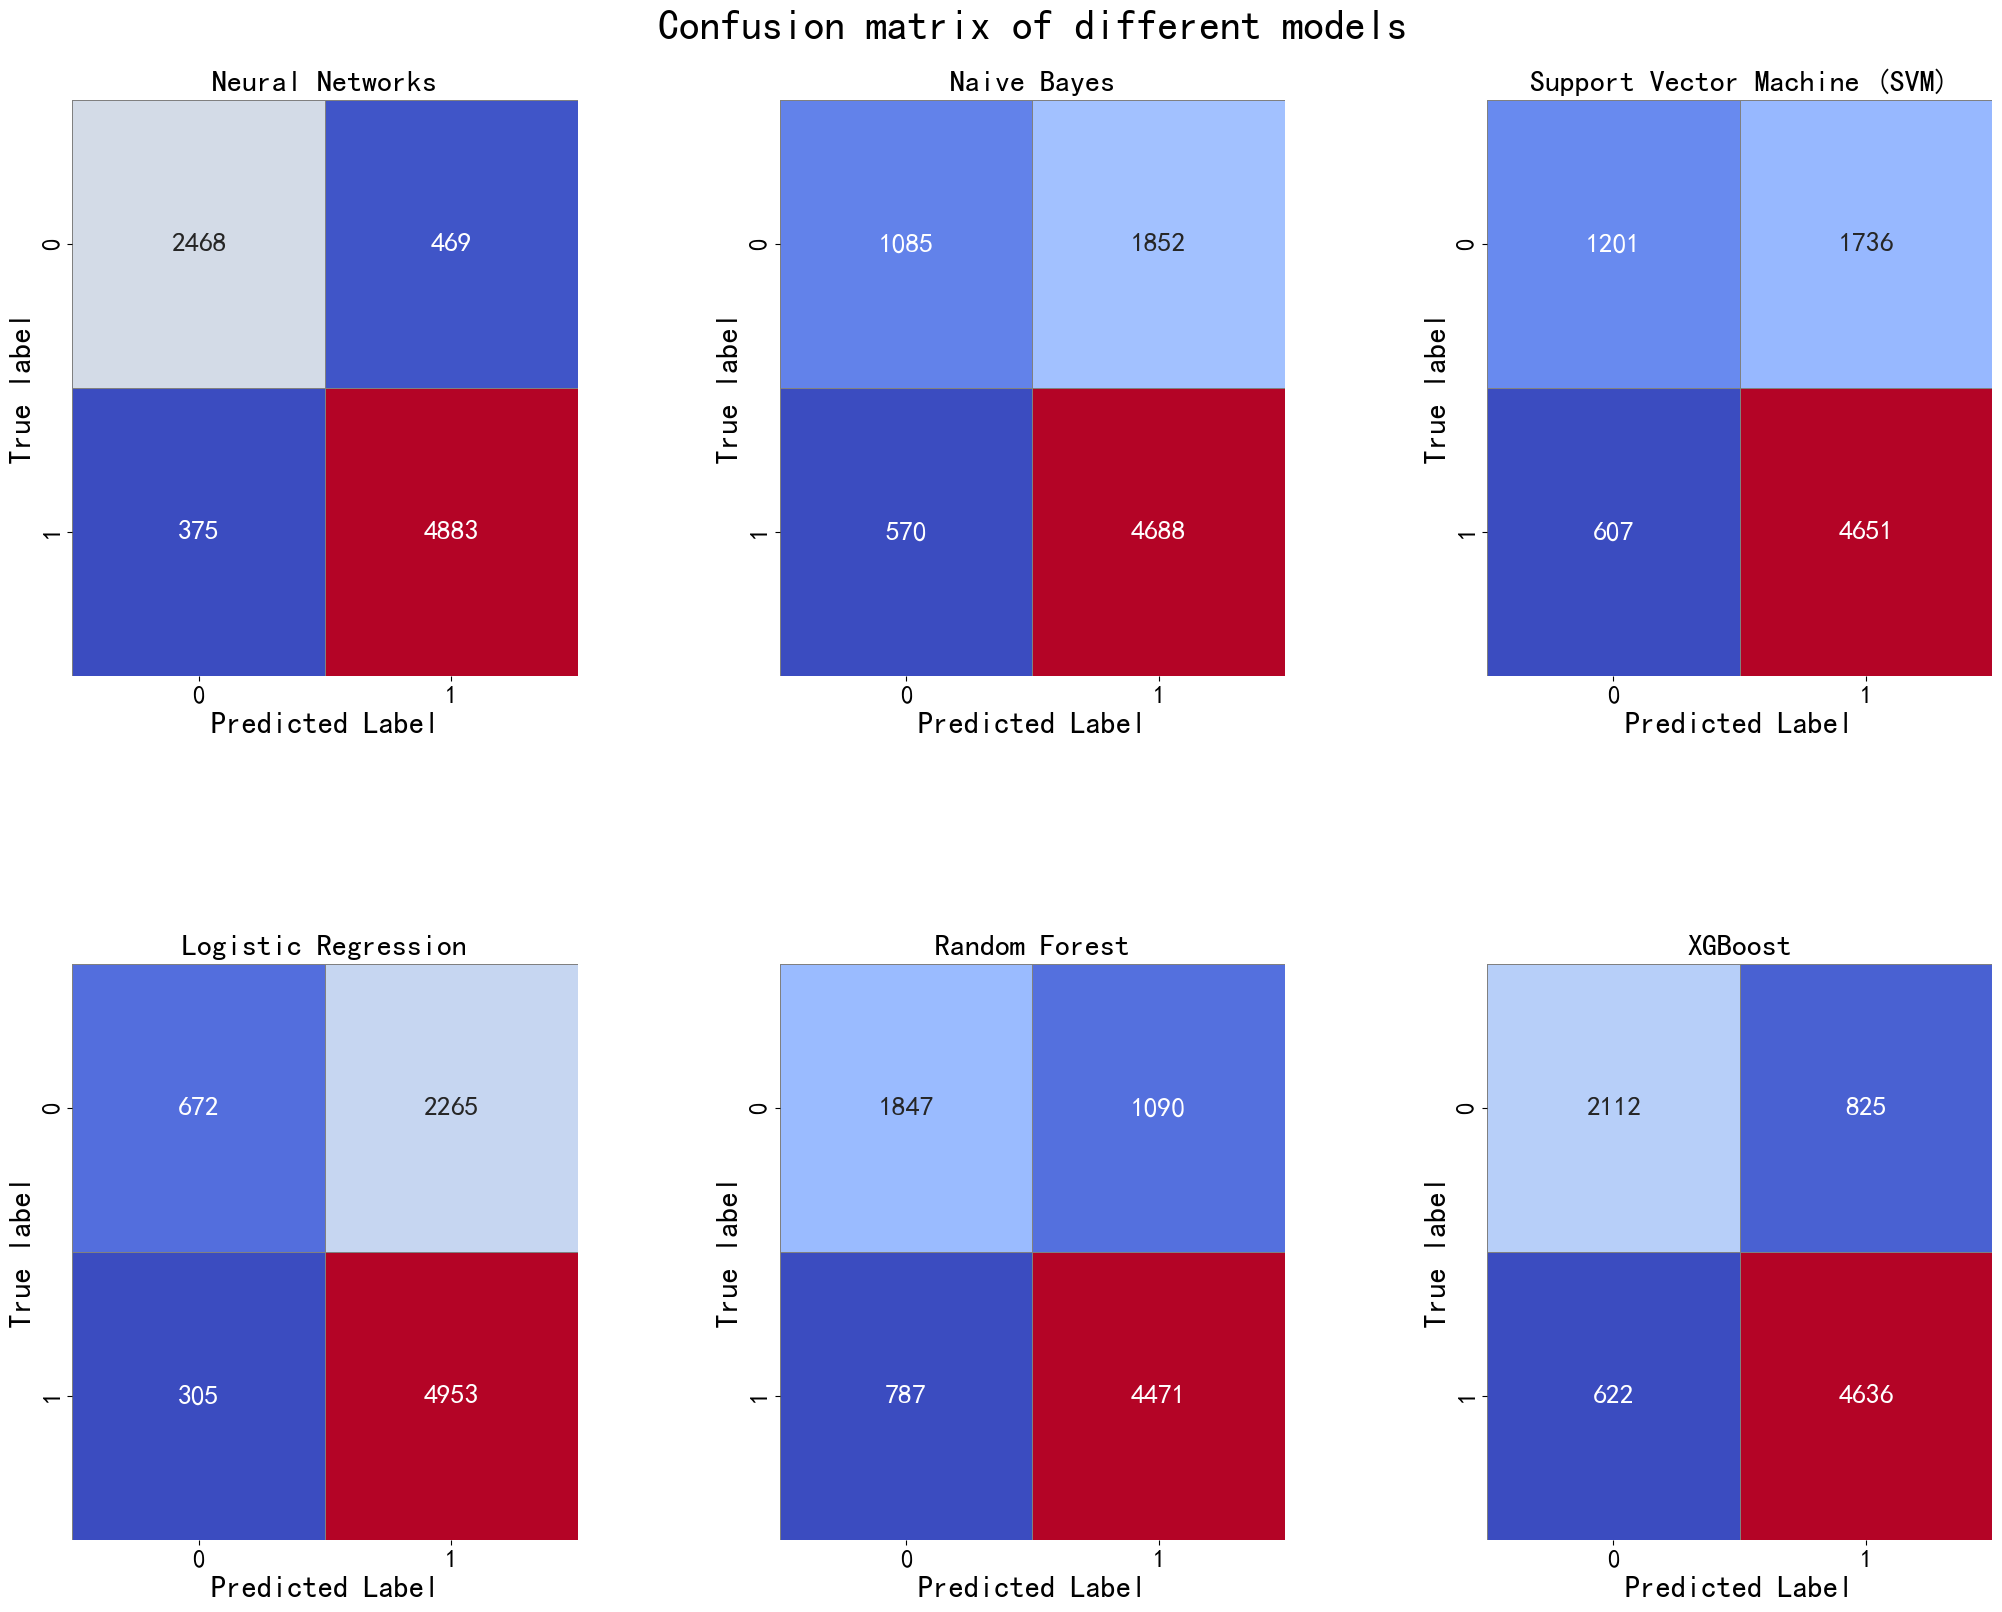

In [26]:
import matplotlib.pyplot as plt
import seaborn as sns

# 假设所有预测结果和真实标签已经定义
lr_cm = confusion_matrix(y_test, lr_preds)
nb_cm = confusion_matrix(y_test, nb_preds)
svm_cm = confusion_matrix(y_test, sv_preds)
nn_cm = confusion_matrix(y_test, y_preds)
rf_cm = confusion_matrix(y_test, rf_preds)
xg_cm = confusion_matrix(y_test, xg_preds)

plt.rc('font', size=18)

plt.figure(figsize=(24, 18))
plt.suptitle("Confusion matrix of different models", fontsize=30, y=0.95)

models = ['Neural Networks', 'Naive Bayes', 'Support Vector Machine (SVM)', 'Logistic Regression', 'Random Forest', 'XGBoost']
# models = ['神经网络', '朴素贝叶斯', '支持向量机 (SVM)', '逻辑回归', '随机森林', 'XGBoost']
cms = [nn_cm, nb_cm, svm_cm, lr_cm, rf_cm, xg_cm]

for i, (model, cm) in enumerate(zip(models, cms), 1):
    plt.subplot(2, 3, i)
    plt.title(model)
    sns.heatmap(cm, cbar=False, cmap="coolwarm", annot=True, annot_kws={"size": 20}, fmt='g', linewidths=0.5, linecolor='gray')
    plt.xlabel('Predicted Label', fontsize=22)
    plt.ylabel('True label', fontsize=22)

plt.subplots_adjust(left=0.1, bottom=0.1, right=0.9, top=0.9, wspace=0.4, hspace=0.5)
plt.show()
def save_fig(fig_id, tight_layout=True, fig_extension="png", resolution=300):
    path = os.path.join(IMAGES_PATH, fig_id + "." + fig_extension)
    print("Saving figure", fig_id)
    if tight_layout:
        plt.tight_layout()
    plt.savefig(path, format=fig_extension, dpi=resolution)


In [27]:
import plotly.graph_objects as go
from sklearn.metrics import roc_curve, auc

# 计算预测概率和ROC曲线
pred_lr = lr.predict_proba(X_test)[:,1]
fpr_lr, tpr_lr, _ = roc_curve(y_test, pred_lr)
roc_auc_lr = auc(fpr_lr, tpr_lr)

pred_nb = nb.predict_proba(X_test)[:,1]
fpr_nb, tpr_nb, _ = roc_curve(y_test, pred_nb)
roc_auc_nb = auc(fpr_nb, tpr_nb)

pred_svm = svm.decision_function(X_test)
fpr_svm, tpr_svm, _ = roc_curve(y_test, pred_svm)
roc_auc_svm = auc(fpr_svm, tpr_svm)

fpr_nn, tpr_nn, _ = roc_curve(y_test, y_preds_prob)
roc_auc_nn = auc(fpr_nn, tpr_nn)

pred_rf = rfc.predict_proba(X_test)[:,1]
fpr_rf, tpr_rf, _ = roc_curve(y_test, pred_rf)
roc_auc_rf = auc(fpr_rf, tpr_rf)

pred_xg = xgb.predict_proba(X_test)[:,1]
fpr_xg, tpr_xg, _ = roc_curve(y_test, pred_xg)
roc_auc_xg = auc(fpr_xg, tpr_xg)


In [28]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# 创建2x3子图布局
fig = make_subplots(
    rows=2, cols=3,
    vertical_spacing=0.15,
    horizontal_spacing=0.08,
    subplot_titles=(
        "LSTM", "Naive Bayes", "Support Vector Machine",
        "Logistic Regression", "Random Forest", "XGBoost"
    )
)

# 定义统一的样式配置
line_styles = {
    'model': dict(width=4, dash='solid'),
    'random': dict(width=2, color='gray', dash='dash')
}

# 添加各模型到子图
models = [
    (fpr_nn, tpr_nn, roc_auc_nn, 1, 1, 'darkred'),
    (fpr_nb, tpr_nb, roc_auc_nb, 1, 2, 'blue'),
    (fpr_svm, tpr_svm, roc_auc_svm, 1, 3, 'green'),
    (fpr_lr, tpr_lr, roc_auc_lr, 2, 1, 'purple'),
    (fpr_rf, tpr_rf, roc_auc_rf, 2, 2, 'orange'),
    (fpr_xg, tpr_xg, roc_auc_xg, 2, 3, 'black')
]

for fpr, tpr, auc, row, col, color in models:
    # 添加ROC曲线
    fig.add_trace(
        go.Scatter(
            x=fpr, y=tpr,
            mode='lines',
            name=f'AUC = {auc:.3f}',
            line=dict(color=color, **line_styles['model']),
            showlegend=False
        ),
        row=row, col=col
    )
    
    # 添加参考线
    fig.add_trace(
        go.Scatter(
            x=[0, 1], y=[0, 1],
            mode='lines',
            line=line_styles['random'],
            showlegend=False
        ),
        row=row, col=col
    )

# 全局布局美化
fig.update_layout(
    title=dict(
        text='模型ROC曲线比较',
        x=0.5,
        y=0.97,
        font=dict(size=24, family='SimSun, sans-serif')
    ),
    plot_bgcolor='white',
    margin=dict(t=100, b=50),
    width=1400,
    height=800
)

# 坐标轴统一设置
axis_template = dict(
    showline=True,
    linecolor='black',
    linewidth=1.5,
    mirror=True,
    gridcolor='lightgray',
    gridwidth=0.5
)

for i in range(1, 7):
    fig.update_xaxes(
        title_text='False Positive Rate',
        range=[-0.02, 1.02],
        tick0=0.0,
        dtick=0.2,
        title_font=dict(size=12),
        **axis_template,
        row=(i-1)//3 + 1, col=(i-1)%3 + 1
    )
    fig.update_yaxes(
        title_text='True Positive Rate',
        range=[-0.02, 1.02],
        tick0=0.0,
        dtick=0.2,
        title_font=dict(size=12),
        **axis_template,
        row=(i-1)//3 + 1, col=(i-1)%3 + 1
    )

# 添加图例
# 添加图例
for i, (_, _, auc, row, col, color) in enumerate(models):
    fig.add_annotation(
        xref=f"x{i+1}", yref=f"y{i+1}",  # 指定注释对应的子图坐标系
        x=0.95, y=0.05,  # 指定注释的位置，这里是子图右下角
        text=f"AUC = {auc:.3f}",  # 注释文本，显示模型的AUC值
        showarrow=False,  # 不显示箭头
        font=dict(size=12, color=color),  # 文本字体和颜色
        align="right",  # 文本对齐方式为右对齐
        bgcolor="white",  # 背景颜色为白色
        bordercolor=color,  # 边框颜色与文本颜色一致
        borderwidth=1  # 边框宽度为1
    )


fig.show()
def save_fig(figure, file_name):
    figure.write_html(file_name)
# save_fig(fig, '模型ROC曲线比较.html')

end